# Linear Hyperelasticity with full order and reduced order simulation

## Environment Setup

### Directory

In [1]:
import sys
from pathlib import Path
import importlib

# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/syedabidi/Documents/GitHub/scikit-rom


### Standard Imports

In [2]:
from src.skrom.utils.imports import *
from src.skrom.rom.rom_utils import *
from src.skrom.utils.visualization.generate_vtk import *
from src.skrom.utils.reduced_basis.svd import svd_mode_selector
from src.skrom.rom.rom_error_est import *
import src.skrom.problem_classes.master_class_static as master
from src.skrom.utils.visualization.generate_vtk import save_vtk_solution
importlib.import_module("problem_1.problem_def")   # this runs @register_problem

<module 'problem_1.problem_def' from '/Users/syedabidi/Documents/GitHub/scikit-rom/tests/computational_mechanics/dynamic/linear/problem_1/problem_def.py'>

## Full Order Simulation

In [3]:
generate = True

if generate:
    sim = master.fom_simulation(num_snapshots=1)
    sim.run_simulation()

Snap 1/2 params=[9.57729087 0.34969682]


/Users/syedabidi/Documents/GitHub/scikit-rom/src/skrom/utils/dynamics/integrators.py:719: SparseEfficiencyWarning: splu converted its input to CSC format
  M_fac = splu(M_csr.copy())
/Users/syedabidi/Documents/GitHub/scikit-rom/src/skrom/utils/dynamics/integrators.py:723: SparseEfficiencyWarning: splu converted its input to CSC format
  K_fac = splu(K_eff if sp.issparse(K_eff) else sp.csr_matrix(K_eff))


Snap 2/2 params=[4.93131503 0.29314232]
Saved full-order solution → fos_solutions.npy
Saved ROM data             → ROM_simulation_data.npz


### Load Simulation data

In [4]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/computational_mechanics/dynamic/linear/problem_1/ROM_data


##### Custom visualization

In [5]:
save_vtk_time_series(
    sim.fos_solutions[0][0], np.linspace(0,8000,500*5),
    sim_data['mesh'].item(), sim_data['basis'].item(),
    scale = 100,
    run_dir=Path("results/anim"),
    prefix="beam"
)

In [6]:
save_vtk_solution(sim.fos_solutions[0][0][:,-1], sim_data['mesh'].item(), sim_data['basis'].item(), 0.025, Path(os.getcwd()), "statatic_sol")


In [7]:
sim.fos_solutions[0][0][:,-1]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        3.38453595e-04, -4.11408096e-03, -2.00926118e-05])

## Data Generation

### Generate Training Solution Dataset

In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap = len(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


2


### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Parameters

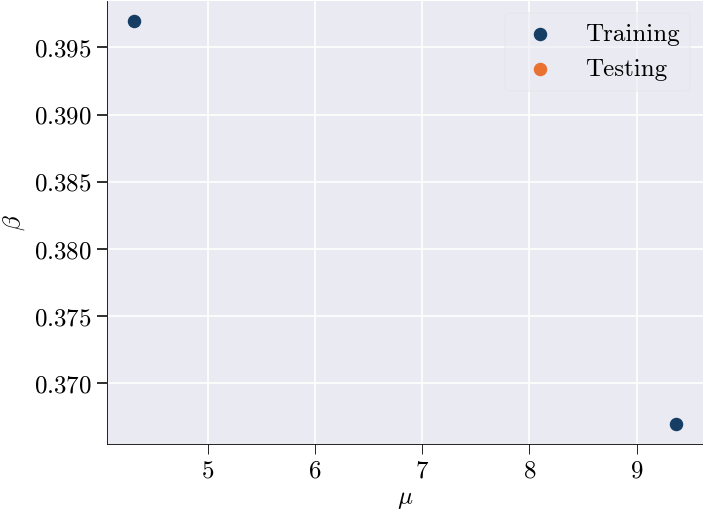

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on solution snapshots

In [10]:
# fig, ax = plt.subplots(figsize=(5,3.5))
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0

n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-4, modes=True)
V_sel = U[:, :n_sel]
plt.ylabel('$1-r_{k}$')
plt.xlabel('POD modes ($k$)')

LinAlgError: SVD did not converge

## ROM Simulation

In [ ]:
#Run ROM simulation here:

rom = master.rom_simulation(V_sel = V_sel)

In [ ]:
rom.run_rom_simulation();

In [ ]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up[1:]
ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

In [ ]:
# --- ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    LS_test,                   # full-order (true) solution snapshots
    LS_rom,              # hyper-ROM-generated solution snapshots
    ROM_relative_error,   # precomputed relative error of the hyper-ROM
    ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

## Visualize on paraview 

In [ ]:
generate_vtk(
    LS_test,
    LS_rom,
    sim_data['mesh'].item(),
    sim_data['basis'].item(),
    scale = 1.0,
    num_test = 5,
    out_dir = "sol_vtk_files",
)